In [1]:
import importlib
from IPython.display import display

try:
    import helpers.preprocess as prep
    import helpers.solver as solv
    import helpers.output_writer as ow
    import helpers.elements_3d as e3d
    import helpers.postprocess as post

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
except ImportError:
    import preprocess as prep
    import solver as solv
    import output_writer as ow
    import elements_3d as e3d
    import postprocess as post

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs

model_path = "inputs/validation/Validation files from previous examples/verification_fabrication_error_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()

display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

Outputs saved to outputs\runs\verification_fabrication_error_frame



,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,verification_fabrication_error_frame,m,kN,3,2,0,2,4,14,2,0.005346


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,2,0.0,10.0,0.0,0.003954,-0.003599,0.0,0.0,0.0,0.025340,0.005346,0.025340
2,3,8.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.021788,0.000000,0.021788


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.0,0.0,0.0,-126.961294,56.74281,0.0,0.0,0.0,223.55542,139.064433,223.55542
1,2,0.0,10.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.00000,0.000000,0.00000
2,3,8.0,10.0,0.0,-113.038706,18.25719,0.0,0.0,0.0,0.00000,114.503599,0.00000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,3D_frame,1,2,56.742810,126.961294,0.0,0.0,0.0,223.555420,-56.742810,113.038706,0.0,0.0,0.0,-153.942483
1,2,3D_frame,2,3,113.038706,56.742810,0.0,0.0,0.0,153.942483,-113.038706,18.257190,0.0,0.0,0.0,0.000000


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,1,3D_frame,1,2,10.0,56.742810,-56.742810,56.742810,126.961294,0.0,0.0,0.0,223.555420,223.555420,11971.057049,-11971.057049,11971.057049
1,2,3D_frame,2,3,8.0,113.038706,-113.038706,113.038706,56.742810,0.0,0.0,0.0,153.942483,153.942483,23847.828348,-23847.828348,23847.828348


In [2]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()
df_disp_key = df_nodes[df_nodes["node_id"].isin([2, 3])][
    ["node_id", "ux", "uy", "rz", "disp_mag", "rot_mag"]
].sort_values("node_id").reset_index(drop=True)
display(df_disp_key)

,node_id,ux,uy,rz,disp_mag,rot_mag
0,2,0.003954,-0.003599,0.025340,0.005346,0.025340
1,3,0.000000,0.000000,0.021788,0.000000,0.021788


In [3]:
df_react = tables["support_reactions"].copy()
df_react_key = df_react[df_react["node_id"].isin([1, 3])][
    ["node_id", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]
].sort_values("node_id").reset_index(drop=True)
display(df_react_key)

,node_id,Rx,Ry,Rz,Mx,My,Mz
0,1,-126.961294,56.74281,0.0,0.0,0.0,223.55542
1,3,-113.038706,18.25719,0.0,0.0,0.0,0.00000


In [4]:
df_local = tables["element_local_end_forces"].copy()
df_local_key = df_local[df_local["elem_id"].isin([1, 2])][
    [
        "elem_id",
        "Fx_i_local", "Fy_i_local", "Fz_i_local",
        "Mx_i_local", "My_i_local", "Mz_i_local",
        "Fx_j_local", "Fy_j_local", "Fz_j_local",
        "Mx_j_local", "My_j_local", "Mz_j_local"
    ]
].sort_values("elem_id").reset_index(drop=True)
display(df_local_key)

,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,56.742810,126.961294,0.0,0.0,0.0,223.555420,-56.742810,113.038706,0.0,0.0,0.0,-153.942483
1,2,113.038706,56.742810,0.0,0.0,0.0,153.942483,-113.038706,18.257190,0.0,0.0,0.0,0.000000


In [5]:
benchmark_rows = [
    {"quantity": "Node 2 ux", "benchmark":  0.00395391, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "ux"].iloc[0])},
    {"quantity": "Node 2 uy", "benchmark": -0.00359855, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "uy"].iloc[0])},
    {"quantity": "Node 2 rz", "benchmark":  0.02534020, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "rz"].iloc[0])},
    {"quantity": "Node 3 rz", "benchmark":  0.02178841, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 3, "rz"].iloc[0])},

    {"quantity": "Node 1 Rx", "benchmark": -126.961294, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Rx"].iloc[0])},
    {"quantity": "Node 1 Ry", "benchmark":  56.742810, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Ry"].iloc[0])},
    {"quantity": "Node 1 Mz", "benchmark": 223.555420, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Mz"].iloc[0])},

    {"quantity": "Node 3 Rx", "benchmark": -113.038706, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Rx"].iloc[0])},
    {"quantity": "Node 3 Ry", "benchmark":  18.257190, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Ry"].iloc[0])},
]

df_compare = pd.DataFrame(benchmark_rows)
df_compare["difference"] = df_compare["code"] - df_compare["benchmark"]

def pct_diff(row):
    b = row["benchmark"]
    if abs(b) < 1e-14:
        return None
    return 100.0 * (row["code"] - b) / b

df_compare["percent_difference"] = df_compare.apply(pct_diff, axis=1)
display(df_compare)

,quantity,benchmark,code,difference,percent_difference
0,Node 2 ux,0.003954,0.003954,3.133934e-09,7.926164e-05
1,Node 2 uy,-0.003599,-0.003599,-2.852445e-09,7.926650e-05
2,Node 2 rz,0.025340,0.025340,-5.366071e-10,-2.117612e-06
3,Node 3 rz,0.021788,0.021788,2.711921e-09,1.244662e-05
4,Node 1 Rx,-126.961294,-126.961294,3.711761e-07,-2.923538e-07
5,Node 1 Ry,56.742810,56.742810,4.117668e-07,7.256721e-07
6,Node 1 Mz,223.555420,223.555420,-4.176271e-07,-1.868114e-07
7,Node 3 Rx,-113.038706,-113.038706,-3.711761e-07,3.283620e-07
8,Node 3 Ry,18.257190,18.257190,-4.117668e-07,-2.255368e-06


In [6]:
benchmark_local_rows = [
    {
        "elem_id": 1,
        "Fx_i_bench":  56.742810,
        "Fy_i_bench": 126.961294,
        "Mz_i_bench": 223.555420,
        "Fx_j_bench": -56.742810,
        "Fy_j_bench": 113.038706,
        "Mz_j_bench": -153.942483,
    },
    {
        "elem_id": 2,
        "Fx_i_bench": 113.038706,
        "Fy_i_bench":  56.742810,
        "Mz_i_bench": 153.942483,
        "Fx_j_bench": -113.038706,
        "Fy_j_bench":  18.257190,
        "Mz_j_bench":   0.0,
    },
]

df_local_bench = pd.DataFrame(benchmark_local_rows)
df_local_compare = df_local_key.merge(df_local_bench, on="elem_id", how="left")
display(df_local_compare)

,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local,Fx_i_bench,Fy_i_bench,Mz_i_bench,Fx_j_bench,Fy_j_bench,Mz_j_bench
0,1,56.742810,126.961294,0.0,0.0,0.0,223.555420,-56.742810,113.038706,0.0,0.0,0.0,-153.942483,56.742810,126.961294,223.555420,-56.742810,113.038706,-153.942483
1,2,113.038706,56.742810,0.0,0.0,0.0,153.942483,-113.038706,18.257190,0.0,0.0,0.0,0.000000,113.038706,56.742810,153.942483,-113.038706,18.257190,0.000000


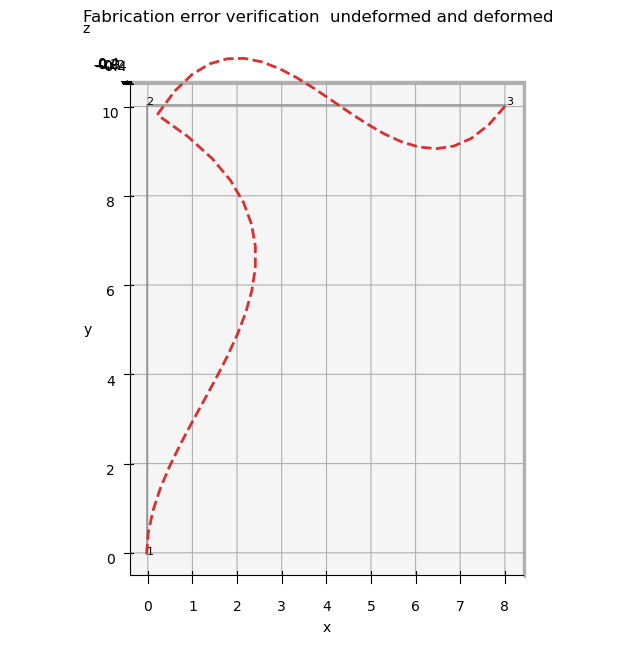

In [7]:
import importlib

try:
    import helpers.plotting_simple as ps
    importlib.reload(ps)
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import plotting_simple as ps
    importlib.reload(ps)
    from plotting_simple import plot_structure_simple

fig, ax = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=60.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=True,
    show_element_labels=False,
    title="Fabrication error verification  undeformed and deformed",
    view="xy",
    save_path="outputs/validation/simple_plots/verification_fabrication_error_frame.png",
)

In [9]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)
    from plotting_plotly import plot_structure_plotly

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=60.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_member_loads=True,
    member_load_scale=0.02,
    title="Fabrication error verification interactive",
    save_html="outputs/validation/plotly_plots/verification_fabrication_error_frame.html",
    save_png="outputs/validation/plotly_plots/verification_fabrication_error_frame.png",
)

fig.show()